In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

print(tf.__version__)

2.20.0


In [2]:
MODEL_PATH = r"C:\Users\arif.arshad\Desktop\MicroAI\models\mix_train_2class.keras"

model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        "preprocess_input": tf.keras.applications.mobilenet_v2.preprocess_input
    },
    safe_mode=False,
    compile=False
)

print("Model loaded successfully!")
model.summary()


Model loaded successfully!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [4]:
CLEAN_TEST_DIR = r"C:\Users\arif.arshad\Desktop\MicroAI\test_clean"

clean_test_ds = tf.keras.utils.image_dataset_from_directory(
    CLEAN_TEST_DIR,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

print(clean_test_ds.class_names)
print("Test batches:", tf.data.experimental.cardinality(clean_test_ds).numpy())

Found 1000 files belonging to 2 classes.
['colon_aca', 'colon_n']
Test batches: 32


In [4]:
UGLY_TEST_DIR = r"C:\Users\arif.arshad\Desktop\MicroAI\test_ugly"

ugly_test_ds = tf.keras.utils.image_dataset_from_directory(
    UGLY_TEST_DIR,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

print(ugly_test_ds.class_names)
print("Test batches:", tf.data.experimental.cardinality(ugly_test_ds).numpy())

Found 1000 files belonging to 2 classes.
['colon_aca', 'colon_n']
Test batches: 32
['colon_aca', 'colon_n']
Test batches: 32


In [ ]:
y_true = []
y_pred = []

for images, labels in clean_test_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

class_names = clean_test_ds.class_names

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

   colon_aca     0.9705    0.9880    0.9792       500
     colon_n     0.9878    0.9700    0.9788       500

    accuracy                         0.9790      1000
   macro avg     0.9792    0.9790    0.9790      1000
weighted avg     0.9792    0.9790    0.9790      1000



[[494   6]
 [ 15 485]]


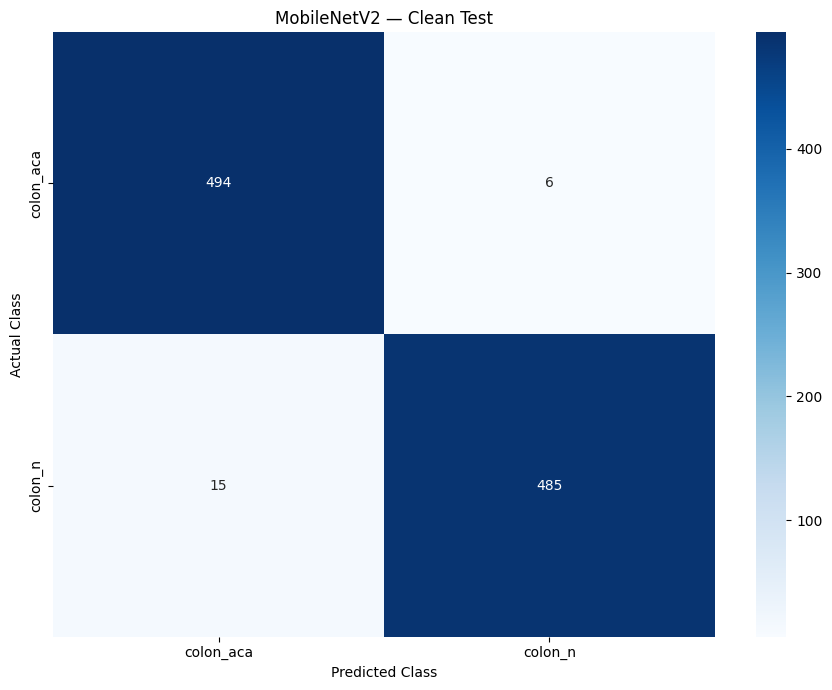

In [28]:
cm_clean = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(9, 7))

print(cm_clean)

sns.heatmap(
    cm_clean,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("MobileNetV2 — Clean Test")

plt.tight_layout()
plt.show()

In [7]:
y_true_ugly = []
y_pred_ugly = []

for images, labels in ugly_test_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true_ugly.extend(labels.numpy())
    y_pred_ugly.extend(predicted_labels)

y_true_ugly = np.array(y_true_ugly)
y_pred_ugly = np.array(y_pred_ugly)

print(
    classification_report(
        y_true_ugly,
        y_pred_ugly,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

   colon_aca     0.9099    0.9700    0.9390       500
     colon_n     0.9679    0.9040    0.9349       500

    accuracy                         0.9370      1000
   macro avg     0.9389    0.9370    0.9369      1000
weighted avg     0.9389    0.9370    0.9369      1000



[[485  15]
 [ 48 452]]


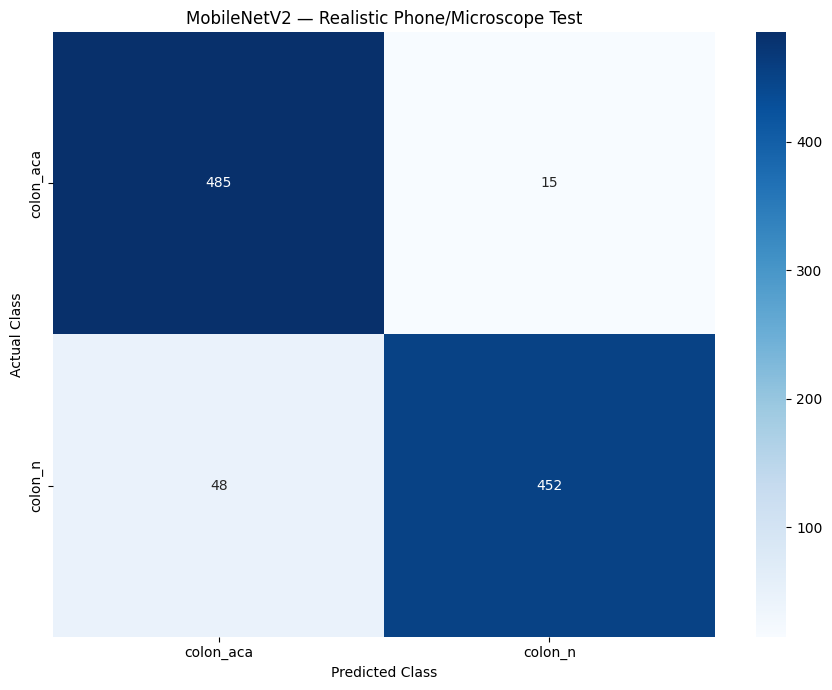

In [29]:
cm_ugly = confusion_matrix(
    y_true_ugly,
    y_pred_ugly
)

plt.figure(figsize=(9, 7))

print(cm_ugly)

sns.heatmap(
    cm_ugly,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("MobileNetV2 — Realistic Phone/Microscope Test")

plt.tight_layout()
plt.show()

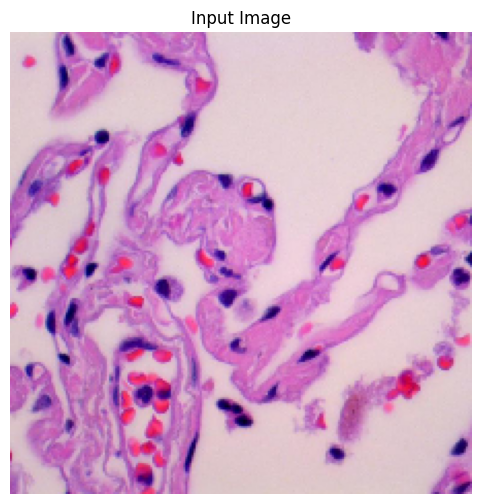


              MicroAI - Prediction

Image                : lungn93.jpeg
Tissue               : Colon
Condition            : Non-cancerous
Specific class       : Normal Colon
Disease probability  : 0.00%
Model confidence     : 85.38%

-------------------------------------------------------
Class probabilities:
  Colon Adenocarcinoma : 14.40%
  Normal Colon         : 85.38%


In [36]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# IMAGE PATH
# ============================================================

IMAGE_PATH = r"C:\Users\arif.arshad\Downloads\archive (1)\lung_colon_image_set\Train and Validation Set\lung_n\lungn93.jpeg"

# ============================================================
# CLASS INFORMATION
# ============================================================

class_names = ["colon_aca", "colon_n"]

# ============================================================
# LOAD IMAGE
# ============================================================

img = tf.keras.utils.load_img(
    IMAGE_PATH,
    target_size=(224, 224)
)

img_array = tf.keras.utils.img_to_array(img)
input_array = np.expand_dims(img_array, axis=0)

# ============================================================
# PREDICT
# ============================================================

predictions = model.predict(input_array, verbose=0)[0]

predicted_index = np.argmax(predictions)
predicted_class = class_names[predicted_index]
confidence = predictions[predicted_index] * 100

# ============================================================
# DISPLAY IMAGE
# ============================================================

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Input Image")
plt.show()

# ============================================================
# INTERPRETATION
# ============================================================

tissue = "Colon"

if predicted_class == "colon_aca":
    condition = "Cancerous"
    specific_class = "Colon Adenocarcinoma"
    disease_probability = predictions[0] * 100
else:
    condition = "Non-cancerous"
    specific_class = "Normal Colon"
    disease_probability = 0.0

# ============================================================
# STRUCTURED OUTPUT
# ============================================================

print("\n" + "=" * 55)
print("              MicroAI - Prediction")
print("=" * 55)

print(f"\nImage                : {os.path.basename(IMAGE_PATH)}")
print(f"Tissue               : {tissue}")
print(f"Condition            : {condition}")
print(f"Specific class       : {specific_class}")
print(f"Disease probability  : {disease_probability:.2f}%")
print(f"Model confidence     : {confidence:.2f}%")

print("\n" + "-" * 55)
print("Class probabilities:")

print(
    f"  Colon Adenocarcinoma : "
    f"{predictions[0] * 100:.2f}%"
)

print(
    f"  Normal Colon         : "
    f"{predictions[1] * 100:.2f}%"
)

print("=" * 55)